imports and read

In [12]:
import pandas as pd
import numpy as np
df = pd.read_csv('.././data/development.csv', index_col=0, header=0).drop(columns='path')

Missing values

In [13]:
df.isna().sum()

sampling_rate             0
age                       0
gender                    0
ethnicity                 0
mean_pitch                0
max_pitch                 0
min_pitch                 0
jitter                    0
shimmer                   0
energy                    0
zcr_mean                  0
spectral_centroid_mean    0
tempo                     0
hnr                       0
num_words                 0
num_characters            0
num_pauses                0
silence_duration          0
dtype: int64

unique values in each column

In [14]:
for col in df.columns:
    print(col, '\t', np.unique(df[col]))

sampling_rate 	 [22050]
age 	 [ 6.   7.  15.  15.5 16.  17.  18.  19.  20.  21.  22.  22.5 23.  24.
 25.  26.  27.  27.5 28.  29.  30.  31.  32.  33.  34.  35.  36.  37.
 38.  39.  40.  41.  42.  43.  44.  45.  46.  47.  48.  49.  50.  51.
 52.  53.  54.  55.  56.  57.  58.  59.  60.  61.  62.  63.  64.  65.
 66.  67.  68.  69.  70.  71.  72.  73.  74.  75.  76.  77.  78.  79.
 80.  81.  82.  83.  84.  85.  86.  88.  90.  97. ]
gender 	 ['female' 'male']
ethnicity 	 ['afemai' 'agni' 'akan' 'albanian' 'amazigh' 'amharic' 'annang' 'arabic'
 'armenian' 'ashanti' 'azerbaijani' 'bafang' 'baga' 'bai' 'bambara'
 'bamun' 'bari' 'basque' 'bavarian' 'belarusan' 'bengali' 'bosnian'
 'bulgarian' 'burmese' 'cameroonian' 'cantonese' 'carolinian' 'catalan'
 'cebuano' 'chaldean' 'chamorro' 'chichewa' 'chittagonian' 'congolese'
 'croatian' 'czech' 'danish' 'dari' 'dinka' 'dutch' 'ebira' 'edo'
 'english' 'estonian' 'ewe' 'fang' 'fanti' 'faroese' 'farsi' 'fataluku'
 'fijian' 'filipino' 'finnish' 'french'

female and males are balanced

In [5]:
df['gender'].value_counts()

gender
female    1468
male      1465
Name: count, dtype: int64

age is not balanced and is not well distributed, being a chi-square distribution

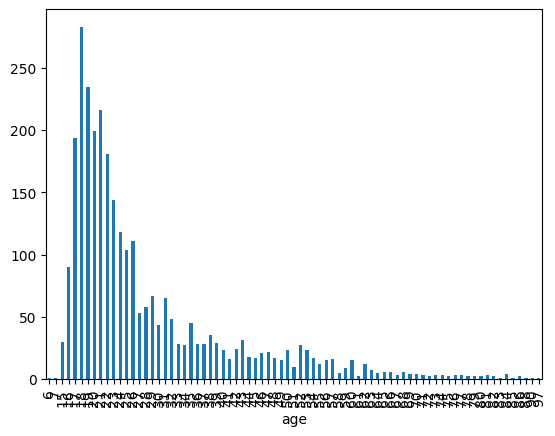

In [18]:
df['age'].map(lambda x:round(x)).value_counts().sort_index().plot.bar();

num words has outliers and is not well distributed

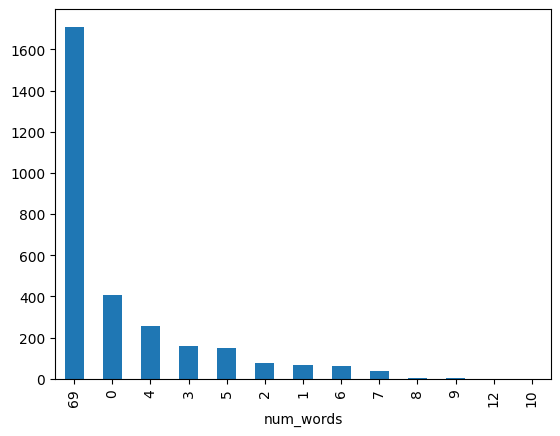

In [23]:
df['num_words'].value_counts().plot.bar();

num characters has outliers and is not well distributed

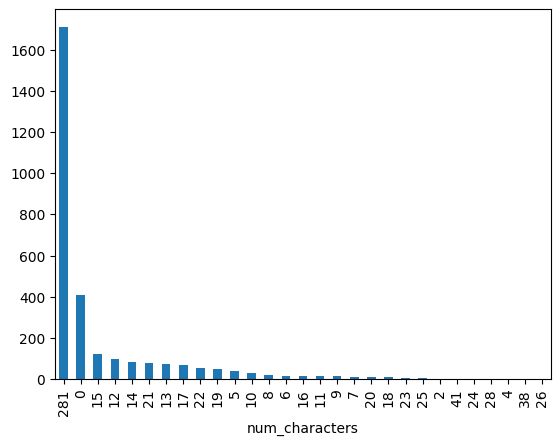

In [22]:
df['num_characters'].value_counts().sort_values(ascending=False).plot.bar();

The sampling rate is the same for each file

In [25]:
np.unique(df['sampling_rate'])

array([22050])

Etnicity is not balanced and is not well distributed

In [27]:
df['ethnicity'].value_counts().sort_values(ascending=False)

ethnicity
igbo        1081
english      579
arabic       102
mandarin      65
french        63
            ... 
hakka          1
malagasy       1
lingala        1
fang           1
rundi          1
Name: count, Length: 165, dtype: int64

Tempo should be preprocessed and converted to float

In [33]:
df['tempo'], df['tempo'].map(lambda x:x[1:-1]).astype(np.float32)

(Id
 0       [151.99908088]
 1       [129.19921875]
 2       [117.45383523]
 3       [117.45383523]
 4       [112.34714674]
              ...      
 2928     [184.5703125]
 2929     [83.35433468]
 2930     [89.10290948]
 2931     [143.5546875]
 2932     [83.35433468]
 Name: tempo, Length: 2933, dtype: object,
 Id
 0       151.999084
 1       129.199219
 2       117.453835
 3       117.453835
 4       112.347145
            ...    
 2928    184.570312
 2929     83.354332
 2930     89.102913
 2931    143.554688
 2932     83.354332
 Name: tempo, Length: 2933, dtype: float32)